In [1]:
%pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import geopandas as gpd
from shapely.geometry import Point
from sklearn.impute import SimpleImputer
import scipy.stats as stats
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from pandas.plotting import parallel_coordinates
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [2]:
# --- Load the master file structure ---
import pickle
import pandas as pd
import os

data_path = "Resampled_Data_split"
with open(os.path.join(data_path, 'file_structure.pkl'), 'rb') as f:
    file_structure = pickle.load(f)

# --- Example of loading the SMOTE set ---
path = file_structure['tomek'] # change smote to other keys as needed : tomek or smote_tomek

X_train = pd.read_parquet(path['X_path'])
# with open(path['y_path'], 'rb') as f: we dont need y for normalizing
#     y_smote_loaded = pickle.load(f)

print("SMOTE data successfully loaded:")
print(f"X shape: {X_train.shape}")
# print(f"y shape: {y_smote_loaded.shape}")

SMOTE data successfully loaded:
X shape: (15911, 64)


In [3]:
# read df_final_merged.geojson file in MergedDatasets
import geopandas as gpd
df_final_merged = gpd.read_file('../../MergedDatasets/df_final_merged.geojson')

# **Normalization**

## **Soil**

In [4]:
# Normalization of soil properties according to property-specific methods
# Create a copy to preserve original values
df_soil_normalized = X_train.copy()
# 
# Small constant to avoid log(0)
EPSILON = 1e-6

In [5]:
# 1) Texture (composition): Min-Max (0-1) scaling
texture_cols = ['COARSE_soil', 'SAND_soil', 'SILT_soil', 'CLAY_soil']
for col in texture_cols:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")


COARSE_soil: Min-Max scaling applied
SAND_soil: Min-Max scaling applied
SILT_soil: Min-Max scaling applied
CLAY_soil: Min-Max scaling applied


In [6]:
# 2) Density & pH: Robust for densities, Min-Max for pH
# Robust scaling: (x - median) / IQR
for col in ['BULK_soil', 'REF_BULK_soil']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

# Min-Max for pH
if 'PH_WATER' in df_soil_normalized.columns:
    col_min = df_soil_normalized['PH_WATER'].min()
    col_max = df_soil_normalized['PH_WATER'].max()
    if col_max > col_min:
        df_soil_normalized['PH_WATER'] = (df_soil_normalized['PH_WATER'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['PH_WATER'] = 0.0
    print("PH_WATER: Min-Max scaling applied")


BULK_soil: Robust scaling applied
REF_BULK_soil: Robust scaling applied


In [7]:
# 3) Organic matter & nutrients
# Log + Robust for ORG_CARBON
if 'ORG_CARBON_soil' in df_soil_normalized.columns:
    # treat non-positive / sentinel values as missing before log
    oc = df_soil_normalized['ORG_CARBON_soil'].copy().astype(float)
    oc.loc[oc <= 0] = np.nan

    # log transform (safe with EPSILON)
    oc = np.log(oc + EPSILON)

    # robust scaling: (x - median) / IQR
    q1 = oc.quantile(0.25)
    q3 = oc.quantile(0.75)
    median = oc.median()
    iqr = q3 - q1
    if iqr > 0:
        oc = (oc - median) / iqr
    else:
        oc = oc - median

    # fill remaining NaNs with median of transformed values (robust fallback)
    oc = oc.fillna(oc.median())

    df_soil_normalized['ORG_CARBON_soil'] = oc
    print("ORG_CARBON: Log + Robust scaling applied")

# Log for TOTAL_N (then standard scale)
if 'TOTAL_N_soil' in df_soil_normalized.columns:
    df_soil_normalized['TOTAL_N_soil'] = np.log(df_soil_normalized['TOTAL_N_soil'] + EPSILON)
    mean_val = df_soil_normalized['TOTAL_N_soil'].mean()
    std_val = df_soil_normalized['TOTAL_N_soil'].std()
    if std_val > 0:
        df_soil_normalized['TOTAL_N_soil'] = (df_soil_normalized['TOTAL_N_soil'] - mean_val) / std_val
    else:
        df_soil_normalized['TOTAL_N_soil'] = 0.0
    print("TOTAL_N: Log + Standard scaling applied")

# Min-Max for TCARBON_EQ
if 'TCARBON_EQ_soil' in df_soil_normalized.columns:
    col_min = df_soil_normalized['TCARBON_EQ_soil'].min()
    col_max = df_soil_normalized['TCARBON_EQ_soil'].max()
    if col_max > col_min:
        df_soil_normalized['TCARBON_EQ_soil'] = (df_soil_normalized['TCARBON_EQ_soil'] - col_min) / (col_max - col_min)
    else:
        df_soil_normalized['TCARBON_EQ_soil'] = 0.0
    print("TCARBON_EQ: Min-Max scaling applied")


ORG_CARBON: Log + Robust scaling applied
TOTAL_N: Log + Standard scaling applied
TCARBON_EQ: Min-Max scaling applied


In [8]:
# 4) Cation exchange & fertility: Robust (CEC_SOIL, CEC_EFF,  TEB), Min-Max (CEC_CLAY, BSAT)
for col in ['CEC_SOIL_soil', 'CEC_EFF_soil', 'TEB_soil']:
    if col in df_soil_normalized.columns:
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Robust scaling applied")

for col in ['CEC_CLAY_soil', 'BSAT_soil']:
    if col in df_soil_normalized.columns:
        col_min = df_soil_normalized[col].min()
        col_max = df_soil_normalized[col].max()
        if col_max > col_min:
            df_soil_normalized[col] = (df_soil_normalized[col] - col_min) / (col_max - col_min)
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Min-Max scaling applied")

CEC_SOIL_soil: Robust scaling applied
CEC_EFF_soil: Robust scaling applied
TEB_soil: Robust scaling applied
CEC_CLAY_soil: Min-Max scaling applied
BSAT_soil: Min-Max scaling applied


In [9]:
# 5) Salinity & saturation: Log + Robust Scaling
for col in ['ALUM_SAT_soil', 'ESP_soil', 'GYPSUM_soil', 'ELEC_COND_soil']:
    if col in df_soil_normalized.columns:
        df_soil_normalized[col] = np.log(df_soil_normalized[col] + EPSILON)
        q1 = df_soil_normalized[col].quantile(0.25)
        q3 = df_soil_normalized[col].quantile(0.75)
        median = df_soil_normalized[col].median()
        iqr = q3 - q1
        if iqr > 0:
            df_soil_normalized[col] = (df_soil_normalized[col] - median) / iqr
        else:
            df_soil_normalized[col] = 0.0
        print(f"{col}: Log + Robust scaling applied")


ALUM_SAT_soil: Log + Robust scaling applied
ESP_soil: Log + Robust scaling applied
GYPSUM_soil: Log + Robust scaling applied
ELEC_COND_soil: Log + Robust scaling applied


In [10]:
print("\nAll normalization transformations completed")
print(f"Original shape: {df_final_merged.shape}")
print(f"Normalized shape: {df_soil_normalized.shape}")



All normalization transformations completed
Original shape: (23180, 48)
Normalized shape: (15911, 64)


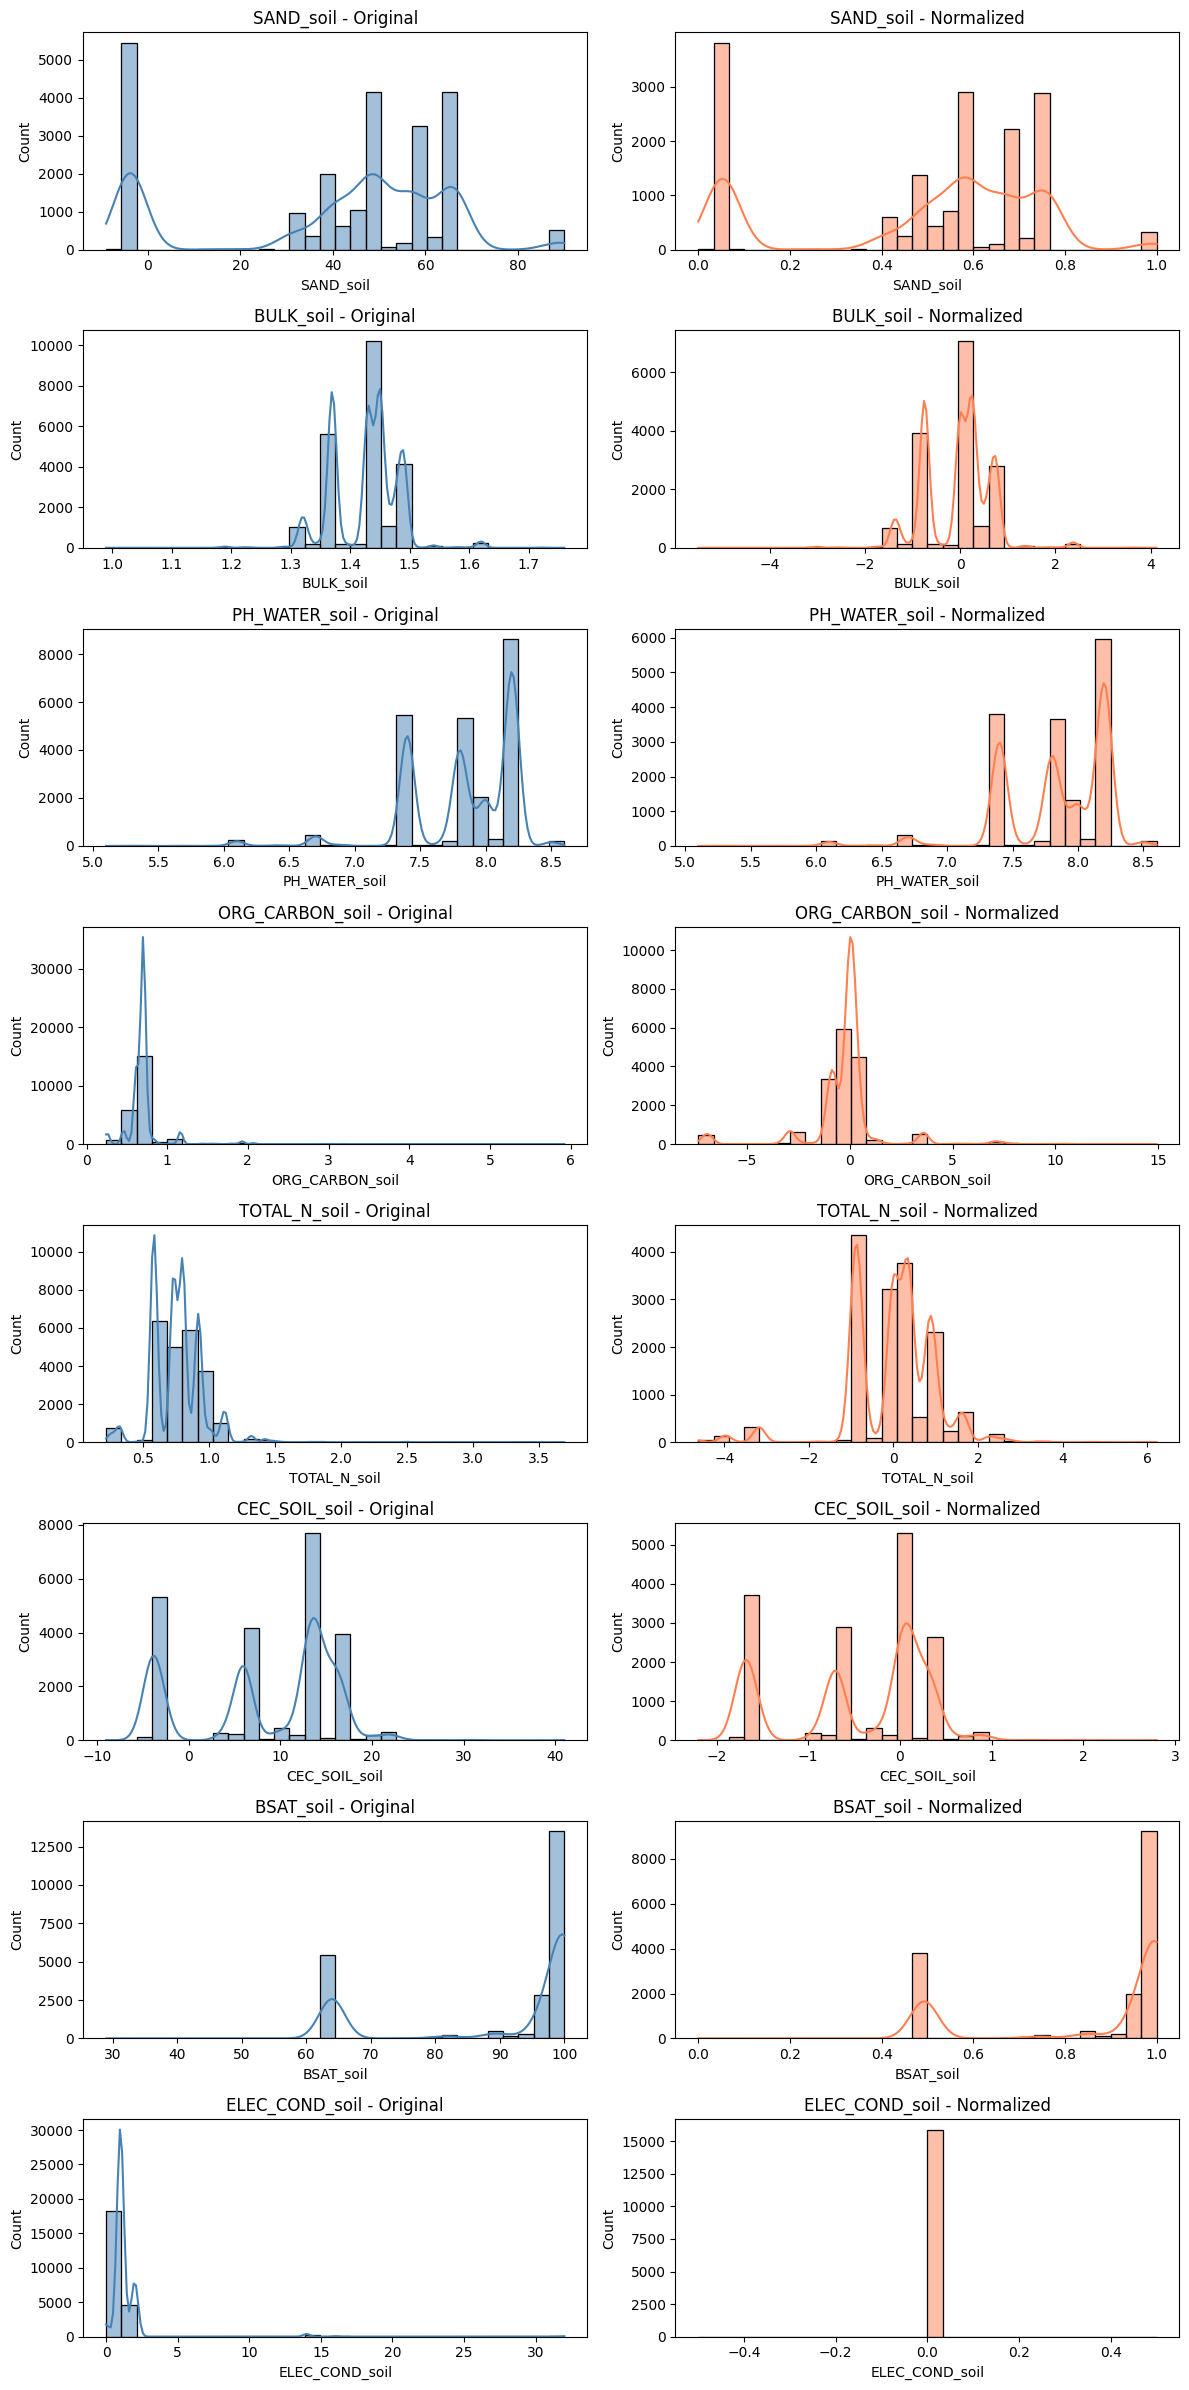

In [11]:
# Compare distributions before and after normalization
# Select a subset of key columns to visualize
comparison_cols = ['SAND_soil', 'BULK_soil', 'PH_WATER_soil', 'ORG_CARBON_soil', 'TOTAL_N_soil', 
                   'CEC_SOIL_soil', 'BSAT_soil', 'ELEC_COND_soil']

# Filter to only columns that exist in both dataframes
comparison_cols = [c for c in comparison_cols if c in df_final_merged.columns and c in df_soil_normalized.columns]

n = len(comparison_cols)
if n > 0:
    ncols = 2  # Before and After side by side
    nrows = n
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3*nrows))
    
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(comparison_cols):
        # Before (original)
        ax_before = axes[i, 0]
        data_before = df_final_merged[col].dropna()
        if not data_before.empty:
            sns.histplot(data_before, bins=30, kde=True, ax=ax_before, color='steelblue')
            ax_before.set_title(f"{col} - Original")
            ax_before.set_xlabel(col)
            ax_before.set_ylabel("Count")
        else:
            ax_before.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_before.transAxes)
        
        # After (normalized)
        ax_after = axes[i, 1]
        data_after = df_soil_normalized[col].dropna()
        if not data_after.empty:
            sns.histplot(data_after, bins=30, kde=True, ax=ax_after, color='coral')
            ax_after.set_title(f"{col} - Normalized")
            ax_after.set_xlabel(col)
            ax_after.set_ylabel("Count")
        else:
            ax_after.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax_after.transAxes)
    
    plt.tight_layout()
    plt.savefig('../../Rapport_TP/images/MergedPreprocess/soil_normalization_comparison.png')
    plt.show()
else:
    print("No columns available for comparison visualization")


In [12]:
# Summary statistics: compare ranges and distributions before/after normalization
numeric_features = ['COARSE_soil', 'SAND_soil', 'SILT_soil', 'CLAY_soil', 'BULK_soil', 'REF_BULK_soil', 
                    'ORG_CARBON_soil', 'PH_WATER_soil', 'TOTAL_N_soil', 'CEC_SOIL_soil', 'CEC_CLAY_soil', 
                    'CEC_EFF_soil', 'TEB_soil', 'BSAT_soil', 'ALUM_SAT_soil', 'ESP_soil', 'TCARBON_EQ_soil', 
                    'GYPSUM_soil', 'ELEC_COND_soil']

# Filter to existing columns
numeric_features = [c for c in numeric_features if c in df_final_merged.columns and c in df_soil_normalized.columns]

summary_comparison = pd.DataFrame({
    'Original_Min': df_final_merged[numeric_features].min(),
    'Original_Max': df_final_merged[numeric_features].max(),
    'Original_Mean': df_final_merged[numeric_features].mean(),
    'Original_Std': df_final_merged[numeric_features].std(),
    'Normalized_Min': df_soil_normalized[numeric_features].min(),
    'Normalized_Max': df_soil_normalized[numeric_features].max(),
    'Normalized_Mean': df_soil_normalized[numeric_features].mean(),
    'Normalized_Std': df_soil_normalized[numeric_features].std()
})

print("Summary Statistics Comparison (Original vs Normalized)")
print("=" * 80)
display(summary_comparison.round(4))


Summary Statistics Comparison (Original vs Normalized)


,Original_Min,Original_Max,Original_Mean,Original_Std,Normalized_Min,Normalized_Max,Normalized_Mean,Normalized_Std
COARSE_soil,-9.000,46.000,7.7714,7.9554,0.0000,1.0000,0.3047,0.1453
SAND_soil,-9.000,90.000,39.7070,26.3766,0.0000,1.0000,0.4903,0.2675
SILT_soil,-9.000,46.000,21.6849,15.6058,0.0000,1.0000,0.5549,0.2844
CLAY_soil,-9.000,55.000,12.3412,10.1603,0.0000,1.0000,0.3311,0.1583
BULK_soil,0.990,1.760,1.4274,0.0543,-5.5000,4.1250,-0.0375,0.6730
REF_BULK_soil,1.200,2.030,1.6499,0.0980,-3.8333,3.0833,-0.0922,0.8077
ORG_CARBON_soil,0.242,5.923,0.6993,0.2168,-7.3756,14.9193,-0.2403,1.7832
PH_WATER_soil,5.100,8.600,7.8345,0.4157,5.1000,8.6000,7.8355,0.4128
TOTAL_N_soil,0.220,3.690,0.7571,0.1913,-4.6141,6.2194,0.0000,1.0000
CEC_SOIL_soil,-9.000,41.000,8.4999,7.8432,-2.2000,2.8000,-0.4600,0.7851


## **Climate**

In [13]:
df_climate_normalized=df_soil_normalized.copy()
# Normalize climate features: Standard scaling (z-score)
temp_features = [c for c in df_climate_normalized.columns if c.startswith('temp_min_') or c.startswith('temp_max_') ]
scaler = StandardScaler()
df_climate_normalized[temp_features] = scaler.fit_transform(df_climate_normalized[temp_features])

In [14]:
# log transform for precipitation
precip_features = [c for c in df_climate_normalized.columns if c.startswith('precip_') ]
for col in precip_features:
    df_climate_normalized[col] = np.log(df_climate_normalized[col] + 1e-6)

## **Elevation**

In [15]:
#standard scaler elevation
elev_features = ['elevation']
scaler_elev = StandardScaler()
df_climate_normalized[elev_features] = scaler_elev.fit_transform(df_climate_normalized[elev_features])

In [16]:
train_set_normalized=df_climate_normalized.copy()

## **LandCover**

no scaling or normalization needed

## **Saving X_train normalized**

In [17]:
# --- Setup Path ---
path = "Normalized_Data_split"
if not os.path.exists(path):
    os.makedirs(path)
print(f"Saving data to directory: {path}")

# 1. Saving X_train (renamed train_set_normalized) in Parquet format
X_train.to_parquet(os.path.join(path, 'X_train_tomek.parquet'), index=False)
print("✓ X_train saved as Parquet.")

Saving data to directory: Normalized_Data_split
✓ X_train saved as Parquet.
